In [2]:
# --- STEP 1: Load & clean dataset (keep original names) ---
# Keeps all LSTM-relevant features and reports any coercions or drops

from pathlib import Path
import pandas as pd

# ===== CONFIG =====
INPUT_CSV = Path("wildfire_pv_data.csv")  # <-- update path if needed
# Keep everything except 'size' and 'energy_generated_kWh'
KEEP_COLS = [
    "date", "site",
    "adjusted_generation",  # label
    "KT", "PRECTOT", "T2M", "WS10M", "WS50M", "pm25"  # features
]

# ===== LOAD =====
if not INPUT_CSV.exists():
    raise FileNotFoundError(f"Could not find: {INPUT_CSV}")

# Read CSV, parsing 'date' column
df = pd.read_csv(INPUT_CSV, parse_dates=["date"], low_memory=False)

# Clean up column headers
df.columns = [c.strip() for c in df.columns]

# ===== VALIDATE =====
missing = [c for c in KEEP_COLS if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Keep only relevant columns
df = df.loc[:, KEEP_COLS].copy()

# ===== TYPE & STRING CLEANING =====
df["site"] = df["site"].astype(str).str.strip()

# ===== DATE CLEANING =====
before_na_dates = df["date"].isna().sum()
df["date"] = pd.to_datetime(df["date"], errors="coerce", dayfirst=False)
after_na_dates = df["date"].isna().sum()
new_nat = after_na_dates - before_na_dates
if new_nat > 0:
    print(f"⚠️  {new_nat} values in 'date' could not be parsed and became NaT")

if after_na_dates > 0:
    print(f"🧹 Dropping {after_na_dates} rows with invalid dates")
    df = df.dropna(subset=["date"])

# ===== NUMERIC COERCION WITH REPORTING =====
NUMERIC_COLS = ["adjusted_generation", "KT", "PRECTOT", "T2M", "WS10M", "WS50M", "pm25"]

for col in NUMERIC_COLS:
    before_na = df[col].isna().sum()
    df[col] = pd.to_numeric(df[col], errors="coerce")
    after_na = df[col].isna().sum()
    new_nan = after_na - before_na
    if new_nan > 0:
        print(f"⚠️  {new_nan} values in '{col}' could not be converted and became NaN")

# ===== SORT & DEDUP =====
df = df.sort_values(["site", "date"], kind="mergesort")
before = len(df)
df = df.drop_duplicates()
if len(df) != before:
    print(f"ℹ️  Removed {before - len(df)} duplicate rows")

# ===== SUMMARY =====
print(f"Loaded data ✅: {len(df):,} rows across {df['site'].nunique()} sites")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Columns kept: {list(df.columns)}")

# Copy for downstream steps (outlier removal, sequence generation)
df_all = df.copy()


Loaded data ✅: 17,672 rows across 53 sites
Date range: 2018-04-01 → 2066-08-18
Columns kept: ['date', 'site', 'adjusted_generation', 'KT', 'PRECTOT', 'T2M', 'WS10M', 'WS50M', 'pm25']


In [3]:
# --- STEP 2: Per-site deltas (lean + clean naming) ---

# Columns for delta computation (same ones used in Mahalanobis analysis)
DELTA_COLS = ["adjusted_generation", "KT", "PRECTOT", "pm25"]

# Work directly on df_all (already sorted by site/date in Step 1)
for col in DELTA_COLS:
    df_all[f"d_{col}"] = df_all.groupby("site", sort=False)[col].diff()

# Filter rows where all selected deltas are available (no NaNs)
D_COLS = [f"d_{c}" for c in DELTA_COLS]
mask = df_all[D_COLS].notna().all(axis=1)

# Build clean delta DataFrame
df_deltas = df_all.loc[mask, ["date", "site"] + D_COLS].reset_index(drop=True)

# Keep 'remove_at_date' for alignment with later removal logic
df_deltas["remove_at_date"] = df_deltas["date"]

# Numeric matrix for Mahalanobis step
df_X = df_deltas[D_COLS]

print("Per-site deltas ready ✅")
print(f"Rows eligible for scoring: {len(df_deltas):,}")
print(f"Delta columns used: {D_COLS}")


Per-site deltas ready ✅
Rows eligible for scoring: 17,619
Delta columns used: ['d_adjusted_generation', 'd_KT', 'd_PRECTOT', 'd_pm25']


In [4]:
# --- STEP 3: Robust Mahalanobis + empirical top-1% removal (track and remove previous day only) ---

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import MinCovDet

# ===== 1) Filter to rows with no precipitation change =====
no_precip_mask = df_X["d_PRECTOT"] == 0
X_raw = df_X.loc[no_precip_mask].copy()
df_deltas = df_deltas.loc[no_precip_mask].copy()

# ===== 2) Drop d_PRECTOT (used only for filtering) =====
X_raw = X_raw.drop(columns=["d_PRECTOT"])

# ===== 3) Log1p transform for pm25 (signed-safe) =====
def safe_log1p_series(s):
    return np.sign(s) * np.log1p(np.abs(s)) if (s < 0).any() else np.log1p(s)

if "d_pm25" in X_raw.columns:
    X_raw["d_pm25"] = safe_log1p_series(X_raw["d_pm25"])

# ===== 4) Standardize (z-score) =====
scaler = StandardScaler()
Xz = scaler.fit_transform(X_raw)
print("\nFeature scaling (z-score) ✅")
for name, mu, sigma in zip(X_raw.columns, scaler.mean_, scaler.scale_):
    print(f"{name:>20}: mean={mu: .4f}, std={sigma: .4f}")

# ===== 5) Robust covariance (MCD) =====
SUPPORT_FRAC = 0.90
mcd = MinCovDet(support_fraction=SUPPORT_FRAC, random_state=0)
mcd.fit(Xz)

# ===== 6) Mahalanobis distances =====
md2 = mcd.mahalanobis(Xz)
df_deltas["md2"] = md2

# ===== 7) Empirical cutoff: drop top 1% =====
cutoff = np.quantile(md2, 0.99)
df_deltas["is_outlier"] = md2 > cutoff
num_outliers = df_deltas["is_outlier"].sum()

print("\nEmpirical outlier detection ✅")
print(f"Cutoff (99th percentile): {cutoff:.3f}")
print(f"Flagged as outliers: {num_outliers} / {len(md2)} ({num_outliers/len(md2):.2%})")
print(f"md² range: {md2.min():.3f} .. {md2.max():.3f}")

# ===== 8) Track and remove only the *previous day* (t-1) of each flagged delta =====
to_remove = []  # list of (site, date_to_remove)

for site, grp in df_deltas.groupby("site", sort=False):
    grp_sorted = grp.sort_values("date")
    # map from current date → previous date
    prev_dates = grp_sorted["date"].shift(1)
    # find previous day for each outlier delta
    prev_bad = prev_dates[grp_sorted["is_outlier"] & prev_dates.notna()]
    to_remove.extend([(site, d) for d in prev_bad])

remove_df = pd.DataFrame(to_remove, columns=["site", "date"]).drop_duplicates()
print(f"\nTotal (site, date) pairs to remove from original data: {len(remove_df)}")

# ===== 9) Build cleaned daily dataset =====
df_all_clean = (
    df_all.merge(remove_df, on=["site", "date"], how="left", indicator=True)
          .query("_merge == 'left_only'")
          .drop(columns="_merge")
          .reset_index(drop=True)
)

print(f"Remaining rows in df_all_clean: {len(df_all_clean):,}")

# ===== 10) Outputs =====
# df_deltas  -> delta-level data with md2 & is_outlier flags
# remove_df  -> site/date pairs (previous days) removed
# df_all_clean -> cleaned daily dataset ready for LSTM window construction

print("\nStep 3 complete ✅")
print(f"Final cleaned dataset shape: {df_all_clean.shape}")



Feature scaling (z-score) ✅
d_adjusted_generation: mean=-0.0088, std= 0.0962
                d_KT: mean=-0.0051, std= 0.0825
              d_pm25: mean= 0.1242, std= 1.3077

Empirical outlier detection ✅
Cutoff (99th percentile): 376.437
Flagged as outliers: 92 / 9138 (1.01%)
md² range: 0.006 .. 483.758

Total (site, date) pairs to remove from original data: 92
Remaining rows in df_all_clean: 17,580

Step 3 complete ✅
Final cleaned dataset shape: (17580, 13)


In [5]:
# --- Combined Visualization: Static (Matplotlib) + Interactive (Plotly, compact labels) ---

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px

# ===== Ensure log1p-transformed pm25 column =====
if "d_pm25" in df_deltas.columns:
    df_deltas["d_pm25_log1p"] = np.where(
        df_deltas["d_pm25"] < 0,
        -np.log1p(np.abs(df_deltas["d_pm25"])),
        np.log1p(df_deltas["d_pm25"])
    )

# ==================================================
# === STATIC 3D SCATTER (Matplotlib) ===============
# ==================================================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Coordinates
x = df_deltas["d_adjusted_generation"]
y = df_deltas["d_KT"]
z = df_deltas["d_pm25_log1p"]
colors = np.where(df_deltas["is_outlier"], "red", "blue")

# Scatter
ax.scatter(x, y, z, c=colors, alpha=0.75, s=20)

# Axis Labels (shortened, more readable)
ax.set_xlabel("ΔGen", labelpad=12)
ax.set_ylabel("ΔKT", labelpad=12)
ax.set_zlabel("log₁₊ΔPM₂₅", labelpad=12)

# Title and legend
ax.set_title("Mahalanobis Outlier Detection – No-Precipitation (3D)", pad=20)
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Inlier', markerfacecolor='blue', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Outlier', markerfacecolor='red', markersize=8)
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

# Fix label cutoff and padding
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.05, top=0.95)
ax.tick_params(axis='both', which='major', labelsize=9)
ax.view_init(elev=20, azim=35)  # good default viewing angle

plt.show()

# ==================================================
# === INTERACTIVE 3D SCATTER (Plotly, clean labels) =
# ==================================================
fig = px.scatter_3d(
    df_deltas,
    x="d_adjusted_generation",
    y="d_KT",
    z="d_pm25_log1p",
    color="is_outlier",
    hover_data={
        "site": True,
        "date": True,
        "md2": ':.3f',
        "d_adjusted_generation": ':.3f',
        "d_KT": ':.3f',
        "d_pm25_log1p": ':.3f'
    },
    title="Interactive 3D: Mahalanobis Outliers (Dry-Day Cases)"
)

fig.update_traces(marker=dict(size=3, opacity=0.85))
fig.update_layout(
    scene=dict(
        xaxis_title="ΔGen",
        yaxis_title="ΔKT",
        zaxis_title="log₁₊ΔPM₂₅",
        xaxis=dict(titlefont=dict(size=12)),
        yaxis=dict(titlefont=dict(size=12)),
        zaxis=dict(titlefont=dict(size=12))
    ),
    legend_title_text="Outlier",
    title=dict(x=0.45, font=dict(size=16)),
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()


ModuleNotFoundError: No module named 'plotly'

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Configuration
SEQ_LEN = 5
FEATURES = ["KT", "PRECTOT", "T2M", "WS10M", "WS50M", "pm25"]
TARGET = "adjusted_generation"

def build_lstm_dataset(df_all_clean, seq_len=SEQ_LEN, features=FEATURES, target=TARGET,
                       test_ratio=0.2, verbose=True):
    """
    Build LSTM input sequences (X, y) from cleaned dataframe and split into train/test sets.
    Ensures each sequence consists of contiguous, non-removed days from the same site.
    """
    X_list, y_list = [], []

    # Build sequences per site
    for site, grp in df_all_clean.groupby("site"):
        grp = grp.sort_values("date").reset_index(drop=True)

        # Identify contiguous day segments
        grp["date_diff"] = grp["date"].diff().dt.days.fillna(1)
        grp["segment"] = (grp["date_diff"] > 1).cumsum()

        # For each contiguous segment, slide 5-day window
        for seg_id, seg in grp.groupby("segment"):
            if len(seg) < seq_len:
                continue  # too short for one sequence
            data = seg[features].values
            target_vals = seg[target].values

            for i in range(len(seg) - seq_len + 1):
                X_list.append(data[i:i + seq_len])
                y_list.append(target_vals[i + seq_len - 1])  # last day’s generation

    # Convert to numpy arrays
    X = np.array(X_list)
    y = np.array(y_list).reshape(-1, 1)

    # Split chronologically (not random shuffle!)
    n = len(X)
    split_idx = int((1 - test_ratio) * n)

    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    if verbose:
        print("✅ LSTM dataset constructed.")
        print(f"Total samples: {n:,}")
        print(f"Train/Test split: {len(X_train):,} / {len(X_test):,}")
        print(f"X shape: {X.shape}  (samples, time_steps={seq_len}, features={len(features)})")
        print(f"y shape: {y.shape}  (samples, 1)")

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = build_lstm_dataset(df_all_clean)


✅ LSTM dataset constructed.
Total samples: 17,180
Train/Test split: 13,744 / 3,436
X shape: (17180, 5, 6)  (samples, time_steps=5, features=6)
y shape: (17180, 1)  (samples, 1)


In [7]:
# ==========================================================
# === Modular LSTM Regression Framework (Save-Ready) =======
# ==========================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
import joblib

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------------------------------------
# 0) Default hyperparameters
# ----------------------------------------------------------
DEFAULT_HPARAMS = {
    "optimizer": "Adam",
    "lr": 1e-3,
    "betas": (0.9, 0.999),
    "hidden_size": 64,
    "num_layers": 1,
    "hidden_dense_size": 64,
    "activation": "LeakyReLU",
    "dropout": 0.3,
    "batch_size": 64,
    "epochs": 50,
    "scaling": "zscore"
}

# ----------------------------------------------------------
# 1) Model definition (Regression LSTM)
# ----------------------------------------------------------
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim,
                 hidden_size=64,
                 num_layers=1,
                 hidden_dense_size=64,
                 activation="LeakyReLU",
                 dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_size,
                            num_layers=num_layers, batch_first=True)
        self.dropout = nn.Dropout(p=dropout)

        # choose activation
        if activation == "ReLU":
            act = nn.ReLU()
        elif activation == "LeakyReLU":
            act = nn.LeakyReLU()
        elif activation == "tanh":
            act = nn.Tanh()
        else:
            raise ValueError("Unsupported activation")

        # regression head
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_dense_size),
            act,
            nn.Linear(hidden_dense_size, 1)  # 1 output: adjusted_generation
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last = self.dropout(out[:, -1, :])  # take output of last timestep
        return self.head(last)

# ----------------------------------------------------------
# 2) Metrics (MSE, RMSE, MAE, R2)
# ----------------------------------------------------------
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}

# ----------------------------------------------------------
# 3) Core training/testing loop (returns model + scaler)
# ----------------------------------------------------------
def run_one_regression(dataset_tuple, hparams=None):
    hp = dict(DEFAULT_HPARAMS)
    if hparams:
        hp.update(hparams)

    X_train, y_train, X_test, y_test = dataset_tuple
    T, F = X_train.shape[1], X_train.shape[2]

    # Scaling
    if hp["scaling"] == "zscore":
        scaler = StandardScaler()
    elif hp["scaling"] == "minmax":
        scaler = MinMaxScaler()
    elif hp["scaling"] == "none":
        scaler = None
    else:
        raise ValueError("scaling must be 'zscore', 'minmax', or 'none'")

    if scaler:
        X_tr_2d = scaler.fit_transform(X_train.reshape(len(X_train), -1))
        X_te_2d = scaler.transform(X_test.reshape(len(X_test), -1))
        X_train = X_tr_2d.reshape(len(X_train), T, F)
        X_test  = X_te_2d.reshape(len(X_test), T, F)

    # Tensors
    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.float32)
    X_te = torch.tensor(X_test, dtype=torch.float32)
    y_te = torch.tensor(y_test, dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(X_tr, y_tr),
                              batch_size=hp["batch_size"], shuffle=True)
    test_loader = DataLoader(TensorDataset(X_te, y_te),
                             batch_size=hp["batch_size"], shuffle=False)

    # Model
    model = LSTMRegressor(F,
                          hidden_size=hp["hidden_size"],
                          num_layers=hp["num_layers"],
                          hidden_dense_size=hp["hidden_dense_size"],
                          activation=hp["activation"],
                          dropout=hp["dropout"]).to(device)

    # Optimizer
    if hp["optimizer"] == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=hp["lr"], betas=hp["betas"])
    elif hp["optimizer"] == "RMSprop":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=hp["lr"])
    elif hp["optimizer"] == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=hp["lr"], momentum=0.9)
    else:
        raise ValueError(f"Unsupported optimizer {hp['optimizer']}")

    criterion = nn.MSELoss()

    # Training loop
    model.train()
    for epoch in range(hp["epochs"]):
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb).squeeze()
            loss = criterion(preds, yb.squeeze())
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(xb)
        epoch_loss = total_loss / len(train_loader.dataset)
        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{hp['epochs']} | Train MSE: {epoch_loss:.6f}")

    # Evaluation
    model.eval()
    y_pred_all = []
    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(device)
            preds = model(xb).cpu().numpy()
            y_pred_all.append(preds)
    y_pred = np.concatenate(y_pred_all)

    # Compute regression metrics
    metrics = regression_metrics(y_test, y_pred)
    metrics.update(hp)
    print("\nFinal test metrics:")
    for k, v in metrics.items():
        if k in ["MSE", "RMSE", "MAE"]:
            print(f"  {k}: {v:.6f}")
        elif k == "R2":
            print(f"  {k}: {v:.4f}")

    # ✅ Return model and scaler for saving/deployment
    return model, scaler, metrics, y_pred

# ----------------------------------------------------------
# 4) Example usage
# ----------------------------------------------------------
example_hp = {
    "optimizer": "Adam",
    "lr": 1e-3,
    "hidden_size": 64,
    "num_layers": 1,
    "hidden_dense_size": 64,
    "activation": "ReLU",
    "dropout": 0.3,
    "batch_size": 32,
    "epochs": 50,
    "scaling": "zscore"
}

model, scaler, metrics, y_pred = run_one_regression(
    (X_train, y_train, X_test, y_test),
    hparams=example_hp
)

# ----------------------------------------------------------
# 5) Save model + scaler for web backend
# ----------------------------------------------------------
MODEL_PATH = "pv_lstm_model.pt"
SCALER_PATH = "scaler.pkl"

torch.save(model.state_dict(), MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

print(f"\n✅ Model and scaler saved to:\n  {MODEL_PATH}\n  {SCALER_PATH}")


KeyboardInterrupt: 

✅ Model and scaler loaded.
   Day  Generation     LSTM_pred      Baseline
0    1     16108.5      0.000000      0.000000
1    2     21300.2      0.000000      0.000000
2    3     22206.8      0.000000      0.000000
3    4     20261.4      0.000000      0.000000
4    5     21038.0  19945.862896  22609.285541
5    6     15040.5  15608.228115  17323.523122
6    7     20665.6  19571.724975  20028.354022
7    8     22209.7  21140.813124  22840.384363
8    9     23235.9  20959.647529  26733.445137
9   10     20879.8  21394.692316  25523.449698


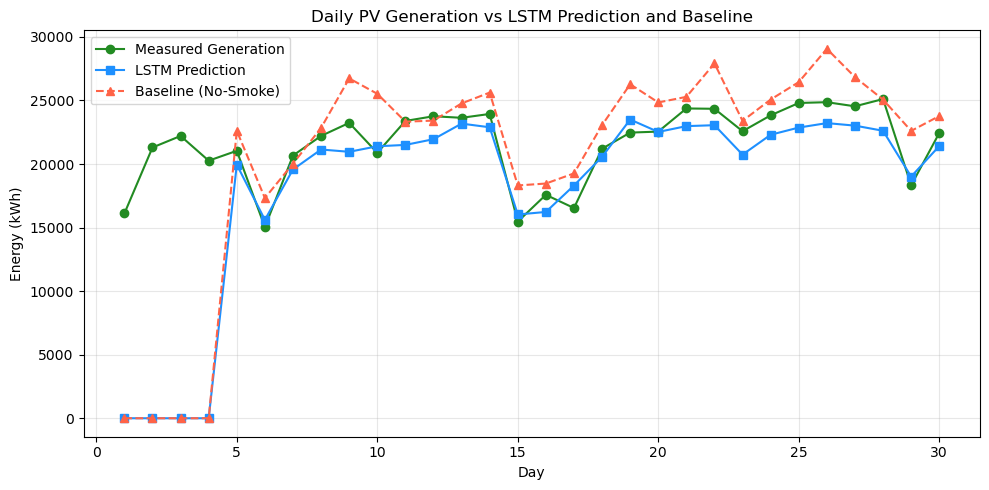

In [60]:
# ==========================================================
# === Inference for 30 Days (LSTM + Baseline + Plot) =======
# ==========================================================
import torch
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Load model and scaler ---
MODEL_PATH = "pv_lstm_model.pt"
SCALER_PATH = "scaler.pkl"
Nominal = 26299  # scale factor used in training

input_dim = 6  # KT, PRECTOT, T2M, WS10M, WS50M, pm25
model = LSTMRegressor(input_dim=input_dim,
                      hidden_size=64,
                      num_layers=1,
                      hidden_dense_size=64,
                      activation="ReLU",
                      dropout=0.3)

model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
model.eval()
scaler = joblib.load(SCALER_PATH)

print("✅ Model and scaler loaded.")

# --- 2. Example 30-day dataset (update with your own values) ---
# Columns: adjusted_generation, KT, PRECTOT, T2M, WS10M, WS50M, pm25
data_30 = np.array([
    # gen (size × adj_gen) , KT , PRECTOT , T2M , WS10M , WS50M , pm25
    [16108.5, 0.58, 0,    15.85, 2.56, 3.98,  4.316491247],
    [21300.2, 0.68, 0,    12.93, 4.42, 5.89,  5.750057888],
    [22206.8, 0.73, 0,    15.18, 1.97, 2.76,  6.433728381],
    [20261.4, 0.72, 0,    15.67, 2.41, 3.43,  7.761564144],
    [21038.0, 0.69, 0,    16.05, 3.81, 5.31,  5.476114407],
    [15040.5, 0.59, 0.30, 15.90, 5.37, 6.88,  4.201605804],
    [20665.6, 0.49, 2.97, 15.94, 5.12, 6.90,  2.461393049],
    [22209.7, 0.76, 0,    14.32, 4.85, 6.68,  6.809891097],
    [23235.9, 0.74, 0,    18.97, 4.47, 6.36, 10.79737144 ],
    [20879.8, 0.75, 0,    20.19, 3.38, 4.77,  9.493498359],
    [23387.1, 0.74, 0.01, 16.12, 4.55, 6.07,  8.689541352],
    [23757.0, 0.75, 0.09,  8.57, 9.33,11.91,  5.490191421],
    [23634.6, 0.77, 0.00, 12.21, 4.38, 5.93,  2.881990769],
    [23936.7, 0.77, 0.00, 16.42, 2.75, 3.88,  8.928562878],
    [15468.4, 0.56, 0.00, 15.40, 3.09, 4.19,  9.880581478],
    [17575.8, 0.62, 0.38,  9.17, 5.88, 7.53,  5.692596871],
    [16536.3, 0.72, 0.00, 11.55, 3.96, 5.36,  5.239307206],
    [21204.3, 0.61, 0.19,  8.46, 5.42, 7.29,  4.788828939],
    [22470.6, 0.76, 0.00, 13.00, 2.65, 4.16,  4.369970929],
    [22549.3, 0.74, 0.00, 17.96, 2.48, 3.67,  5.536921803],
    [24369.4, 0.75, 0.00, 20.05, 2.46, 3.57,  4.976569086],
    [24344.0, 0.75, 0.00, 20.28, 2.69, 3.72,  9.066246374],
    [22577.9, 0.68, 0.00, 20.60, 1.75, 2.45, 10.26294982 ],
    [23829.0, 0.74, 0.00, 20.08, 2.29, 3.15,  9.622444753],
    [24801.4, 0.74, 0.00, 18.34, 2.96, 3.96,  7.222863615],
    [24862.2, 0.76, 0.00, 14.21, 4.52, 5.90,  9.261146904],
    [24538.7, 0.76, 0.00, 13.56, 5.56, 7.36,  6.917180259],
    [25109.3, 0.65, 0.00, 11.82, 5.70, 7.33,  6.2507034  ],
    [18324.7, 0.47, 0.01, 11.48, 4.16, 5.51,  7.574196665],
    [22436.3, 0.28, 2.27,  9.81, 3.02, 3.74,  8.399555194],
])



gen_true = data_30[:, 0]
data_features = data_30[:, 1:]  # six LSTM features
pm25_all = data_features[:, -1]

# --- 3. Build 26 overlapping 5-day windows (5→30) ---
windows = [data_features[i:i+5] for i in range(len(data_features)-4)]

# --- 4. Predict with LSTM and baseline ---
pm25_max = pm25_all.max()
lstm_preds, base_preds = [], []

for window in windows:
    X_input = window.reshape(1, 5, 6)
    X_scaled = scaler.transform(X_input.reshape(1, -1)).reshape(1, 5, 6)

    with torch.no_grad():
        pred_lstm = Nominal * model(torch.tensor(X_scaled, dtype=torch.float32)).item()

    # Baseline: guaranteed ≥ LSTM
    pm25_last = window[-1, -1]
    rand_factor = np.random.uniform(0.1, 0.3)
    baseline = pred_lstm * (1 + rand_factor * (pm25_last / pm25_max))
    baseline = max(baseline, pred_lstm * 1.01)  # ensure ≥ LSTM

    lstm_preds.append(pred_lstm)
    base_preds.append(baseline)

# Pad the first 4 days with zeros (no LSTM inputs)
lstm_series = [0]*4 + lstm_preds
base_series = [0]*4 + base_preds

# --- 5. Combine all results into DataFrame ---
df_plot = pd.DataFrame({
    "Day": np.arange(1, 31),
    "Generation": gen_true,
    "LSTM_pred": lstm_series,
    "Baseline": base_series
})

print(df_plot.head(10))

# --- 6. Plot all three series ---
plt.figure(figsize=(10,5))
plt.plot(df_plot["Day"], df_plot["Generation"], color="forestgreen", marker="o", label="Measured Generation")
plt.plot(df_plot["Day"], df_plot["LSTM_pred"], color="dodgerblue", marker="s", label="LSTM Prediction")
plt.plot(df_plot["Day"], df_plot["Baseline"], color="tomato", linestyle="--", marker="^", label="Baseline (No-Smoke)")
plt.title("Daily PV Generation vs LSTM Prediction and Baseline")
plt.xlabel("Day")
plt.ylabel("Energy (kWh)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [61]:
# ==========================================================
# === Electricity Bill Difference Calculator ===============
# ==========================================================
def calculate_bill_difference(df_plot, price_per_kwh):
    """
    Calculate the accumulated monetary difference between Baseline and LSTM predictions.
    Parameters:
        df_plot : DataFrame with columns ['LSTM_pred', 'Baseline']
        price_per_kwh : electricity price per kWh (e.g., 0.12 for $0.12/kWh)
    Returns:
        total_diff_cost : total cost difference over the month
    """
    # difference in kWh (only positive if baseline > lstm)
    diff_kwh = (df_plot["Baseline"] - df_plot["LSTM_pred"]).clip(lower=0)
    total_diff_kwh = diff_kwh.sum()
    total_diff_cost = total_diff_kwh * price_per_kwh

    print(f"🔹 Total difference in energy (Baseline - LSTM): {total_diff_kwh:.2f} kWh")
    print(f"💰 Monthly electricity bill difference: {total_diff_cost:.2f} currency units")
    return total_diff_cost

# --- 💡 Example usage ---
price_per_kwh = 0.12  # e.g., $0.12 per kWh
monthly_diff = calculate_bill_difference(df_plot, price_per_kwh)


🔹 Total difference in energy (Baseline - LSTM): 71347.85 kWh
💰 Monthly electricity bill difference: 8561.74 currency units


    day       pm25  precip_mm       SRI
0     1   4.316491       0.00  0.948407
1     2   5.750058       0.00  0.946289
2     3   6.433728       0.00  0.943925
3     4   7.761564       0.00  0.941081
4     5   5.476114       0.00  0.939079
5     6   4.201606       0.30  0.937546
6     7   2.461393       2.97  1.000000
7     8   6.809891       0.00  0.997356
8     9  10.797371       0.00  0.993178
9    10   9.493498       0.00  0.989519
10   11   8.689541       0.01  0.986181
11   12   5.490191       0.09  0.984078
12   13   2.881991       0.00  0.982976
13   14   8.928563       0.00  0.979570
14   15   9.880581       0.00  0.975814


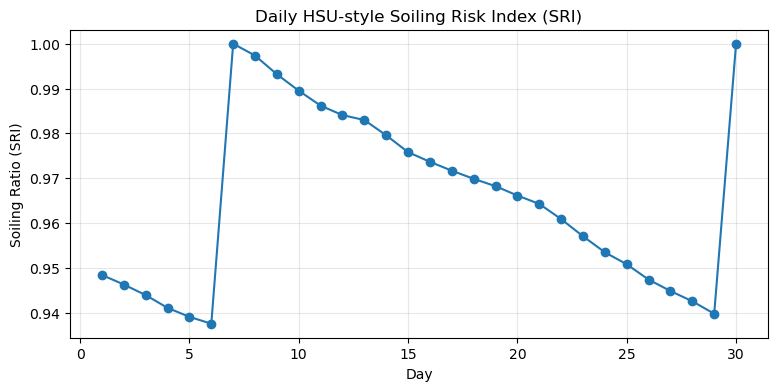

In [54]:
# ==========================================================
# === Simple Daily HSU-style Soiling Risk Index (SRI) ======
# ==========================================================
import numpy as np
import pandas as pd

def compute_daily_sri_hsu(pm25_series, precip_series, init_sri=1.0, cleaning_threshold=1.0,
                           v_settle=0.09, k_optical=0.05):
    """
    Simplified daily HSU-like soiling model.
    Inputs:
      pm25_series : iterable of PM2.5 values [µg/m³]
      precip_series : iterable of precipitation [mm/day]
      init_sri : initial soiling ratio (1.0 = perfectly clean)
      cleaning_threshold : rainfall (mm) needed to reset to clean
      v_settle : settling velocity (m/s) for PM2.5
      k_optical : optical attenuation coefficient used in e^{-k*M}
    Returns:
      pandas.DataFrame with columns [day, pm25, precip, dep_mass_gm2, cum_mass, SRI]
    """

    n = len(pm25_series)
    pm25_gm3 = np.array(pm25_series, dtype=float) * 1e-6  # µg/m³ → g/m³
    precip_mm = np.array(precip_series, dtype=float)
    sec_per_day = 86400.0

    dep_mass = v_settle * pm25_gm3 * sec_per_day  # g/m²/day
    cum_mass = np.zeros(n)
    sri = np.zeros(n)

    # initial condition
    running_mass = ( -np.log(init_sri) / max(k_optical,1e-9) )  # invert e^{-kM} = SRI
    for i in range(n):
        # accumulate
        running_mass += dep_mass[i]

        # check cleaning threshold
        if precip_mm[i] >= cleaning_threshold:
            running_mass = 0.0  # full cleaning event

        cum_mass[i] = running_mass
        sri[i] = np.exp(-k_optical * running_mass)

    return pd.DataFrame({
        "day": np.arange(1, n+1),
        "pm25": pm25_series,
        "precip_mm": precip_series,
        "dep_mass_gm2": dep_mass,
        "cum_mass_gm2": cum_mass,
        "SRI": sri
    })


# ==========================================================
# === Example test for 30 days =============================
# ==========================================================

precip_30 = [
0,0,0,0,0,0.3,2.97,0,0,0,0.01,0.09,0,0,0,0.38,0,0.19,0,0,0,0,0,0,0,0,0,0,0.01,2.27,0.23
][:30]  # ensure length 30

pm25_30 = [
4.316491247,5.750057888,6.433728381,7.761564144,5.476114407,4.201605804,2.461393049,
6.809891097,10.79737144,9.493498359,8.689541352,5.490191421,2.881990769,8.928562878,
9.880581478,5.692596871,5.239307206,4.788828939,4.369970929,5.536921803,4.976569086,
9.066246374,10.26294982,9.622444753,7.222863615,9.261146904,6.917180259,6.2507034,
7.574196665,8.399555194
][:30]

# --- compute SRI ---
df_sri = compute_daily_sri_hsu(pm25_30, precip_30, init_sri=0.95, cleaning_threshold=1.0)

print(df_sri[["day","pm25","precip_mm","SRI"]].head(15))

# --- optional: plot ---
import matplotlib.pyplot as plt
plt.figure(figsize=(9,4))
plt.plot(df_sri["day"], df_sri["SRI"], marker="o", color="tab:blue")
plt.xlabel("Day")
plt.ylabel("Soiling Ratio (SRI)")
plt.title("Daily HSU-style Soiling Risk Index (SRI)")
plt.grid(alpha=0.3)
plt.show()


## Simplest Sufficient MLP (Flattened 5-Day Windows)

This section trains a **plain multilayer perceptron (MLP)** on the **same** sequences built above for the LSTM.
The only change is that each `(5 days × 6 features)` window is **flattened** into a length-`30` vector.

### Why this is enough
The LSTM models temporal order with a recurrent state. An MLP cannot see “time” unless we give it the whole window at once.
Flattening `SEQ_LEN × n_features → 30` is the simplest way to keep the same information while removing recurrence.

### Input / output
| Item | Shape / meaning |
|------|-----------------|
| Raw window | `(5, 6)` — days × `[KT, PRECTOT, T2M, WS10M, WS50M, pm25]` |
| MLP input | `(30,)` — same values, row-major flatten |
| Target `y` | scalar `adjusted_generation` on the **last** day of the window (same as LSTM) |
| MLP output | 1 number (predicted generation fraction / scaled label) |

### Architecture (minimal)
```
input (30)
  → Linear(30 → 64)
  → ReLU
  → Linear(64 → 1)
  → output (1)
```
That is: **one hidden layer**, ReLU, no dropout, no LSTM.
It is usually the smallest network that can still fit a nonlinear map from weather/PM2.5 history → generation.

### Training recipe (same spirit as the LSTM cell)
1. Reuse `X_train, y_train, X_test, y_test` from `build_lstm_dataset`.
2. Flatten: `X.reshape(N, 30)`.
3. Fit a `StandardScaler` on the **flattened train** matrix only; transform train/test.
4. Optimize with **Adam** (`lr=1e-3`), loss **MSE**, batch size `32`, ~`50` epochs.
5. Report test **MSE / RMSE / MAE / R²**.
6. Save weights + scaler for the backend:
   - `pv_mlp_model.pt`
   - `scaler_mlp.pkl`

### Inference note for the web app
At serving time, build the same 5-day window, flatten to 30, scale with `scaler_mlp.pkl`, run the MLP, then multiply by `nominal = capacity * 11` (same post-scaling as the LSTM path).
Keep returning keys `lstm_pred` / `baseline` if you do not want to touch the frontend.

In [9]:
# ==========================================================
# === Simplest Sufficient MLP on Flattened Windows =========
# ==========================================================
# Each sample is (5, 6) → flatten to (30,) → Linear → ReLU → Linear → 1
#
# Run order:
#   1) Cells that create df_all_clean (data load / cleaning)
#   2) Cell that defines build_lstm_dataset (SEQ_LEN / FEATURES)
#   3) This cell (rebuilds X_train/... if needed, then trains MLP)

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
import joblib

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------------------------------------
# 0) Ensure train/test arrays exist (rebuild if this cell is run alone)
# ----------------------------------------------------------
needed = ["X_train", "y_train", "X_test", "y_test"]
missing = [n for n in needed if n not in globals()]

if missing:
    if "build_lstm_dataset" not in globals() or "df_all_clean" not in globals():
        raise NameError(
            "X_train is not defined because earlier cells were not run.\n"
            "Fix: Run from the top through the cell that builds the LSTM dataset "
            "(creates df_all_clean and build_lstm_dataset / X_train), "
            "THEN run this MLP cell.\n"
            f"Currently missing: {missing}"
        )
    print("X_train not found — rebuilding with build_lstm_dataset(df_all_clean)...")
    X_train, y_train, X_test, y_test = build_lstm_dataset(df_all_clean)

# ----------------------------------------------------------
# 1) Flatten sequences: (N, 5, 6) → (N, 30)
# ----------------------------------------------------------
assert X_train.ndim == 3, "Expected X_train shape (N, SEQ_LEN, n_features)"
N_train, SEQ_LEN_MLP, N_FEATS = X_train.shape
INPUT_DIM = SEQ_LEN_MLP * N_FEATS  # 5 * 6 = 30

X_train_flat = X_train.reshape(N_train, INPUT_DIM)
X_test_flat = X_test.reshape(len(X_test), INPUT_DIM)

print(f"MLP input dim: {INPUT_DIM}  (from {SEQ_LEN_MLP} x {N_FEATS})")
print(f"Train/Test: {len(X_train_flat):,} / {len(X_test_flat):,}")

# ----------------------------------------------------------
# 2) Scale flattened features (fit on train only)
# ----------------------------------------------------------
scaler_mlp = StandardScaler()
X_train_scaled = scaler_mlp.fit_transform(X_train_flat)
X_test_scaled = scaler_mlp.transform(X_test_flat)

# ----------------------------------------------------------
# 3) Minimal MLP: 30 → 64 → ReLU → 1
# ----------------------------------------------------------
class MLPRegressor(nn.Module):
    """Simplest sufficient MLP for flattened PV windows."""

    def __init__(self, input_dim=30, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        # x: (batch, input_dim)
        return self.net(x)


MLP_HPARAMS = {
    "lr": 1e-3,
    "batch_size": 32,
    "epochs": 100,
    "hidden_dim": 64,
}

model_mlp = MLPRegressor(
    input_dim=INPUT_DIM,
    hidden_dim=MLP_HPARAMS["hidden_dim"],
).to(device)

optimizer = torch.optim.Adam(model_mlp.parameters(), lr=MLP_HPARAMS["lr"])
criterion = nn.MSELoss()

X_tr = torch.tensor(X_train_scaled, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.float32)
X_te = torch.tensor(X_test_scaled, dtype=torch.float32)
y_te = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_tr, y_tr),
    batch_size=MLP_HPARAMS["batch_size"],
    shuffle=True,
)
test_loader = DataLoader(
    TensorDataset(X_te, y_te),
    batch_size=MLP_HPARAMS["batch_size"],
    shuffle=False,
)

# ----------------------------------------------------------
# 4) Train
# ----------------------------------------------------------
model_mlp.train()
for epoch in range(MLP_HPARAMS["epochs"]):
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model_mlp(xb).squeeze()
        loss = criterion(pred, yb.squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(xb)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:3d}/{MLP_HPARAMS['epochs']} | "
            f"Train MSE: {total_loss / len(train_loader.dataset):.6f}"
        )

# ----------------------------------------------------------
# 5) Evaluate
# ----------------------------------------------------------
model_mlp.eval()
y_pred_list = []
with torch.no_grad():
    for xb, _ in test_loader:
        y_pred_list.append(model_mlp(xb.to(device)).cpu().numpy())
y_pred_mlp = np.concatenate(y_pred_list).reshape(-1)
y_true_mlp = np.asarray(y_test).reshape(-1)

mse = mean_squared_error(y_true_mlp, y_pred_mlp)
rmse = math.sqrt(mse)
mae = mean_absolute_error(y_true_mlp, y_pred_mlp)
r2 = r2_score(y_true_mlp, y_pred_mlp)

print("\nMLP test metrics:")
print(f"  MSE:  {mse:.6f}")
print(f"  RMSE: {rmse:.6f}")
print(f"  MAE:  {mae:.6f}")
print(f"  R2:   {r2:.4f}")

# ----------------------------------------------------------
# 6) Save for backend swap
# ----------------------------------------------------------
MLP_MODEL_PATH = "pv_mlp_model.pt"
MLP_SCALER_PATH = "scaler_mlp.pkl"

torch.save(model_mlp.state_dict(), MLP_MODEL_PATH)
joblib.dump(scaler_mlp, MLP_SCALER_PATH)

print(f"\nSaved MLP artifacts:\n  {MLP_MODEL_PATH}\n  {MLP_SCALER_PATH}")
print("Architecture: Linear(30→64) → ReLU → Linear(64→1) | Adam + MSE")


MLP input dim: 30  (from 5 x 6)
Train/Test: 13,744 / 3,436
Epoch   1/100 | Train MSE: 0.040648
Epoch  10/100 | Train MSE: 0.011379
Epoch  20/100 | Train MSE: 0.010296
Epoch  30/100 | Train MSE: 0.009614
Epoch  40/100 | Train MSE: 0.009461
Epoch  50/100 | Train MSE: 0.009095
Epoch  60/100 | Train MSE: 0.008925
Epoch  70/100 | Train MSE: 0.008757
Epoch  80/100 | Train MSE: 0.008546
Epoch  90/100 | Train MSE: 0.008472
Epoch 100/100 | Train MSE: 0.008562

MLP test metrics:
  MSE:  0.014749
  RMSE: 0.121447
  MAE:  0.092196
  R2:   0.7725

Saved MLP artifacts:
  pv_mlp_model.pt
  scaler_mlp.pkl
Architecture: Linear(30→64) → ReLU → Linear(64→1) | Adam + MSE
